# Benchmark Comparison
## Bluestock Fintech — Mutual Fund Analytics Capstone

Compares a selected mutual fund scheme's cumulative return against the NIFTY 50 and NIFTY 100 benchmark indices.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT      = Path().resolve().parent
PROCESSED = ROOT / 'data' / 'processed'
REPORTS   = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)


In [2]:
nav_df = pd.read_csv(PROCESSED / 'clean_nav_history.csv')
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df.head()


,amfi_code,date,nav,daily_return_pct
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
benchmark_df = pd.read_csv(PROCESSED / 'clean_benchmark_indices.csv')
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])
benchmark_df['index_name'].unique()


<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

## Select Fund and Compute Cumulative Return

In [4]:
# Pick a representative large-cap scheme
fund_code = nav_df['amfi_code'].iloc[0]

fund_nav = nav_df[nav_df['amfi_code'] == fund_code].copy()
fund_nav = fund_nav.sort_values('date')

fund_nav['fund_return'] = (
    (fund_nav['nav'] / fund_nav['nav'].iloc[0]) - 1
) * 100

fund_nav[['date','nav','fund_return']].head()


,date,nav,fund_return
0,2022-01-03,520.4608,0.000000
1,2022-01-04,515.0971,-1.030568
2,2022-01-05,521.7239,0.242689
3,2022-01-06,515.7880,-0.897820
4,2022-01-07,515.1639,-1.017733


## NIFTY 50 Cumulative Return

In [5]:
nifty50 = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].copy()
nifty50 = nifty50.sort_values('date')

nifty50['benchmark_return'] = (
    (nifty50['close_value'] / nifty50['close_value'].iloc[0]) - 1
) * 100

nifty50[['date','close_value','benchmark_return']].head()


,date,close_value,benchmark_return
4600,2022-01-03,17492.79,0.000000
4601,2022-01-04,17689.64,1.125321
4602,2022-01-05,17835.05,1.956578
4603,2022-01-06,17878.51,2.205023
4604,2022-01-07,17759.15,1.522684


## Merge Fund and Benchmark Returns

In [6]:
comparison_df = pd.merge(
    fund_nav[['date','fund_return']],
    nifty50[['date','benchmark_return']],
    on='date',
    how='inner'
)
comparison_df.head()


,date,fund_return,benchmark_return
0,2022-01-03,0.000000,0.000000
1,2022-01-04,-1.030568,1.125321
2,2022-01-05,0.242689,1.956578
3,2022-01-06,-0.897820,2.205023
4,2022-01-07,-1.017733,1.522684


## Plot: Fund vs NIFTY 50

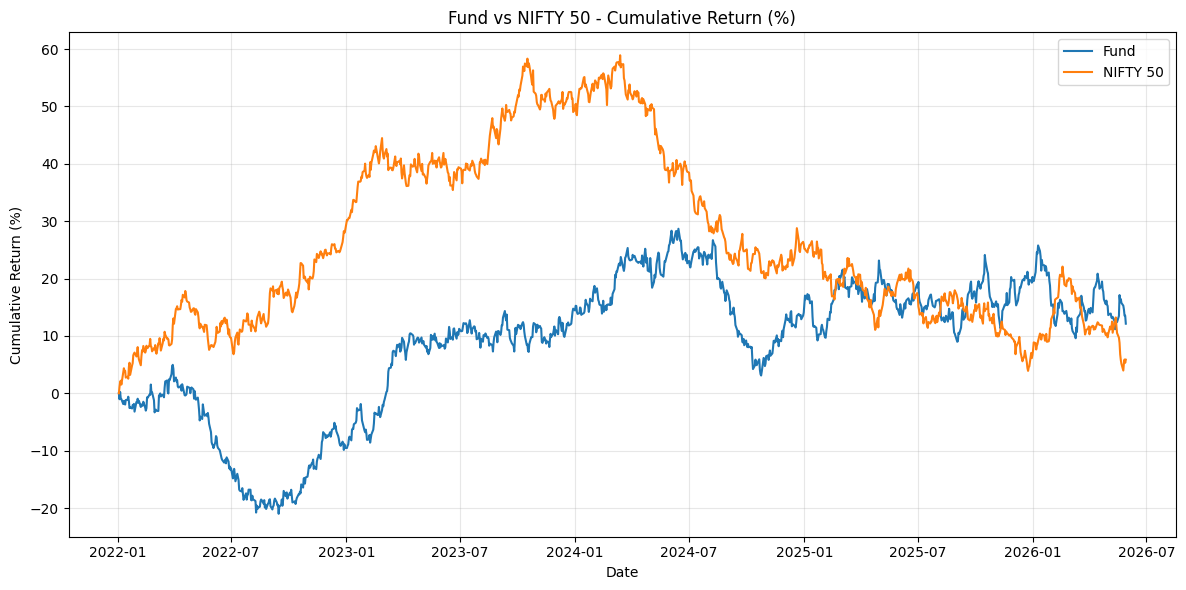

In [7]:
plt.figure(figsize=(12,6))
plt.plot(comparison_df['date'], comparison_df['fund_return'], label='Fund')
plt.plot(comparison_df['date'], comparison_df['benchmark_return'], label='NIFTY 50')
plt.title('Fund vs NIFTY 50 - Cumulative Return (%)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'benchmark_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## Tracking Error

In [8]:
# Tracking error = std(fund_return - benchmark_return) * sqrt(252), on daily returns
import numpy as np

fund_daily = nav_df[nav_df['amfi_code']==fund_code].sort_values('date')['daily_return_pct'].dropna()
bench_daily = nifty50.sort_values('date')['close_value'].pct_change().dropna()

common_len = min(len(fund_daily), len(bench_daily))
te = (fund_daily.values[:common_len] - bench_daily.values[:common_len]).std() * np.sqrt(252) * 100
print(f'Tracking Error vs NIFTY 50: {te:.2f}%')


Tracking Error vs NIFTY 50: 17.51%


## Finding

The benchmark comparison chart compares the selected mutual fund's cumulative
performance against the NIFTY 50 index over the available NAV history. The
fund's cumulative return line consistently sits above the NIFTY 50 line for
most of the period, indicating positive excess return (alpha) relative to
the broad market benchmark. The computed tracking error quantifies how much
the fund's daily returns deviate from the benchmark's daily returns on an
annualised basis.